# Неделя 5 — уточнение квантильной калибровки

## 1. Идея эксперимента

В предыдущем Week 5 notebook мы заменили фиксированный conservative shift на quantile prediction по деревьям RandomForest. Это улучшило MAE и снизило долю overestimation. Однако в том эксперименте использовался один общий RUL cap, один общий quantile и один общий shift для всех двигателей.

В этом notebook мы проверяем более гибкую настройку:
- возможно, после quantile calibration оптимальный RUL cap отличается от 125;
- один quantile для всех двигателей может быть слишком грубым;
- разные зоны predicted RUL могут требовать разных quantile;
- uncertainty RandomForest можно использовать для выбора более осторожного прогноза.

Цель — попытаться опустить MAE ниже результата предыдущего Week 5 без перехода к тяжёлым нейросетям.

## 2. Imports and configuration

In [1]:
import hashlib
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

random_state = RANDOM_STATE
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = Path("CMAPSSData")

current_best_mae = 9.27
previous_best_q = 0.35
previous_best_shift = 0.5
previous_best_cap = 125
previous_best_overestimation_share_fallback = 0.40

cap_grid = [115, 120, 125, 130, 135, 140, 150]
quantile_grid = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
shift_grid = np.arange(0, 3.5, 0.5)

piecewise_near_q_grid = [0.40, 0.45, 0.50]
piecewise_warning_q_grid = [0.30, 0.35, 0.40]
piecewise_long_q_grid = [0.25, 0.30, 0.35, 0.40]
piecewise_shift_grid = np.arange(0, 3.0, 0.5)

uncertainty_quantile_pairs = [
    (0.40, 0.30),
    (0.45, 0.30),
    (0.45, 0.25),
    (0.50, 0.30),
    (0.50, 0.25),
]

uncertainty_threshold_grid = ["median", "q60", "q70", "q75", "q80"]

final_rf_base = {"n_estimators": 400, "random_state": RANDOM_STATE, "n_jobs": -1}

columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

target_col = "Remaining Useful Life"
eps = 1e-6
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

In [2]:
def none_if_missing(value):
    if value is None:
        return None
    if isinstance(value, str) and value in {"None", "nan", "NaN", ""}:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return value


def parse_rf_max_features(value):
    value = none_if_missing(value)
    if value is None:
        return None
    if isinstance(value, str):
        if value in {"sqrt", "log2"}:
            return value
        try:
            return float(value)
        except ValueError:
            return value
    return value


best_week4_candidate = {
    "selected_blocks": [
        "delta",
        "edge_means",
        "first",
        "last_minus_mean",
        "max",
        "mean",
        "median",
        "min",
        "range",
        "slope",
        "slope_change",
        "std",
        "tail_quantiles",
        "volatility",
    ],
    "window_size": 40,
    "rul_cap": 125,
    "rf_max_depth": 24,
    "rf_min_samples_leaf": 3,
    "rf_min_samples_split": 2,
    "rf_max_features": 0.4,
}
old_week4_shift = 2.0
pd.DataFrame([{**best_week4_candidate, "week4_shift": old_week4_shift}])

,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,week4_shift
0,"[delta, edge_means, first, last_minus_mean, ma...",40,125,24,3,2,0.4,2.0


## 3. Data loading

Используем FD001: train, test и official RUL. Для train целевая переменная считается как разница между последним циклом двигателя и текущим циклом. Для official test используем последнее доступное окно каждого test unit и истинный RUL из `RUL_FD001.txt`.

In [3]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_table(
        data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    test_df = pd.read_table(
        data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    rul_test_df = pd.read_table(
        data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
    )
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    return train_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_source_cols = [
    col
    for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

pd.DataFrame(
    {
        "dataset": ["train", "test", "official_rul"],
        "rows": [len(train_df), len(test_df), len(rul_test_df)],
        "units": [
            train_df["unit_id"].nunique(),
            test_df["unit_id"].nunique(),
            len(rul_test_df),
        ],
    }
)

,dataset,rows,units
0,train,20631,100
1,test,13096,100
2,official_rul,100,100


## 4. Воспроизведение лучшего Week 5 baseline

Воспроизводим лучшую Week 4 RandomForest-модель и предыдущую Week 5 quantile-калибровку: cap около 125, q около 0.35 и небольшой conservative shift.

In [4]:
all_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
    "median",
    "iqr",
    "first",
    "last",
    "relative_delta",
    "relative_last_minus_mean",
    "rms",
    "edge_means",
    "slope_change",
    "tail_quantiles",
    "robust_spread",
    "volatility",
]


def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x**2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"


def expected_feature_columns(config):
    suffixes_by_block = {
        "edge_means": ["first_edge", "last_edge"],
        "tail_quantiles": ["q10", "q90"],
    }
    result = []
    for block_name in config["selected_blocks"]:
        for suffix in suffixes_by_block.get(block_name, ["value"]):
            for source_col in feature_source_cols:
                result.append(
                    feature_name(source_col, block_name, suffix, config["window_size"])
                )
    return result


def make_block_frame(block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [
                feature_name(col, block_name, suffix, window_size)
                for col in frame.columns
            ]
            frames.append(frame)
        return pd.concat(frames, axis=1)
    frame = block_values.copy()
    frame.columns = [
        feature_name(col, block_name, "value", window_size) for col in frame.columns
    ]
    return frame


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=window_size, min_periods=min_periods
    )
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=edge_window_size, min_periods=edge_min_periods
    )
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(
        window_size - 1
    )
    if not require_full_window:
        first_features = first_features.fillna(
            sorted_df.groupby("unit_id")[feature_source_cols].transform("first")
        )
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": max_features - min_features,
        "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(
            level=0, drop=True
        ),
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": q75_features - q25_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + eps),
        "relative_last_minus_mean": last_minus_mean_features
        / (mean_features.abs() + eps),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {
            "first_edge": rolling.apply(
                lambda values: np.mean(values[:edge_window_size]), raw=True
            ).reset_index(level=0, drop=True),
            "last_edge": edge_rolling.mean().reset_index(level=0, drop=True),
        },
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(
            level=0, drop=True
        ),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(
            level=0, drop=True
        ),
    }
    return pd.concat(
        [
            make_block_frame(block, block_values[block], window_size)
            for block in config["selected_blocks"]
        ],
        axis=1,
    )

In [5]:
def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("Пустая история cutoff")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)],
            "std": [("value", float(np.std(values)))],
            "min": [("value", min_value)],
            "max": [("value", max_value)],
            "range": [("value", max_value - min_value)],
            "delta": [("value", last_value - first_value)],
            "slope": [("value", calculate_slope(values))],
            "last_minus_mean": [("value", last_value - mean_value)],
            "median": [("value", float(np.median(values)))],
            "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)],
            "last": [("value", last_value)],
            "relative_delta": [
                ("value", (last_value - first_value) / (abs(first_value) + eps))
            ],
            "relative_last_minus_mean": [
                ("value", (last_value - mean_value) / (abs(mean_value) + eps))
            ],
            "rms": [("value", calculate_rms(values))],
            "edge_means": [
                ("first_edge", float(np.mean(values[:edge_window_size]))),
                ("last_edge", float(np.mean(values[-edge_window_size:]))),
            ],
            "slope_change": [("value", calculate_slope_change(values))],
            "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)],
            "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in config["selected_blocks"]:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    return row


def build_aggregated_features_for_units(
    df, config, mode, validation_cutoffs=None, cap_target=True
):
    expected_columns = expected_feature_columns(config)
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=True
        )
        result_df = pd.concat(
            [sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1
        )
        result_df = (
            result_df[result_df["cycle"] >= config["window_size"]]
            .dropna()
            .reset_index(drop=True)
        )
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if cap_target and config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=False
        )
        result_df = (
            pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1)
            .dropna()
            .reset_index(drop=True)
        )
        last_rows = (
            result_df.sort_values(["unit_id", "cycle"])
            .groupby("unit_id")
            .tail(1)
            .sort_values("unit_id")
            .reset_index(drop=True)
        )
        return last_rows[expected_columns], last_rows["unit_id"].reset_index(drop=True)
    if mode == "validation_cutoff":
        grouped = {
            unit_id: unit_df.sort_values("cycle")
            for unit_id, unit_df in df.groupby("unit_id")
        }
        rows = []
        y_values = []
        ids = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            raise ValueError("Validation-признаки содержат NaN")
        return X, pd.Series(y_values), pd.Series(ids)
    raise ValueError(f"Unknown mode: {mode}")

In [6]:
def build_rf_params(candidate, base):
    params = base.copy()
    params.update(
        {
            "max_depth": candidate["rf_max_depth"],
            "min_samples_leaf": candidate["rf_min_samples_leaf"],
            "min_samples_split": candidate["rf_min_samples_split"],
            "max_features": candidate["rf_max_features"],
        }
    )
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_df = pd.DataFrame(
        {
            "model_name": model_name,
            "id": ids,
            "true_rul": np.asarray(y_true),
            "pred_rul": np.asarray(y_pred),
        }
    )
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_subset(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    return error_df


def compute_week4_fitness(metrics):
    near_mae = (
        metrics["near_failure_MAE"]
        if not pd.isna(metrics["near_failure_MAE"])
        else metrics["MAE"]
    )
    warning_mae = (
        metrics["warning_zone_MAE"]
        if not pd.isna(metrics["warning_zone_MAE"])
        else metrics["MAE"]
    )
    return (
        metrics["MAE"]
        + 4.0 * metrics["overestimation_share"]
        + 0.08 * near_mae
        + 0.04 * warning_mae
        + 0.03 * metrics["max_overestimation"]
    )


def metrics_from_error(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset(error_df, "near_failure")
    warning = zone_subset(error_df, "warning_zone")
    metrics = {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": (
            mean_absolute_error(near["true_rul"], near["pred_rul"])
            if len(near)
            else np.nan
        ),
        "warning_zone_MAE": (
            mean_absolute_error(warning["true_rul"], warning["pred_rul"])
            if len(warning)
            else np.nan
        ),
    }
    metrics["fitness"] = compute_week4_fitness(metrics)
    return metrics


def metrics_row(model_name, prediction_type, y_true, y_pred, ids=None, extra=None):
    error_df = build_error_table(y_true, y_pred, model_name, ids)
    row = {
        "model_name": model_name,
        "prediction_type": prediction_type,
        **metrics_from_error(error_df),
    }
    if extra:
        row.update(extra)
    return row, error_df


def safety_summary(error_df):
    return pd.DataFrame(
        {
            "zone": ["near_failure", "warning_zone", "all"],
            "count": [
                len(zone_subset(error_df, "near_failure")),
                len(zone_subset(error_df, "warning_zone")),
                len(error_df),
            ],
            "MAE": [
                (
                    metrics_from_error(zone_subset(error_df, "near_failure"))["MAE"]
                    if len(zone_subset(error_df, "near_failure"))
                    else np.nan
                ),
                (
                    metrics_from_error(zone_subset(error_df, "warning_zone"))["MAE"]
                    if len(zone_subset(error_df, "warning_zone"))
                    else np.nan
                ),
                metrics_from_error(error_df)["MAE"],
            ],
            "overestimation_share": [
                (
                    float((zone_subset(error_df, "near_failure")["error"] > 0).mean())
                    if len(zone_subset(error_df, "near_failure"))
                    else np.nan
                ),
                (
                    float((zone_subset(error_df, "warning_zone")["error"] > 0).mean())
                    if len(zone_subset(error_df, "warning_zone"))
                    else np.nan
                ),
                float((error_df["error"] > 0).mean()),
            ],
        }
    )


def rul_zone_analysis(error_df):
    bins = [-1, 30, 70, 125, np.inf]
    labels = ["0-30", "31-70", "71-125", "126+"]
    zoned = error_df.copy()
    zoned["rul_zone"] = pd.cut(zoned["true_rul"], bins=bins, labels=labels)
    rows = []
    for zone, group in zoned.groupby("rul_zone", observed=False):
        if len(group):
            rows.append(
                {
                    "rul_zone": str(zone),
                    "count": len(group),
                    **metrics_from_error(group),
                }
            )
    return pd.DataFrame(rows)

In [7]:
metric_columns = [
    "fitness",
    "MAE",
    "RMSE",
    "R2",
    "mean_error",
    "overestimation_share",
    "max_overestimation",
    "near_failure_MAE",
    "warning_zone_MAE",
]
display_columns = ["method", "cap", "q", "quantile_strategy", "shift", *metric_columns]

base_candidate = best_week4_candidate.copy()
base_candidate["rul_cap"] = previous_best_cap
X_train_base, y_train_base_raw = build_aggregated_features_for_units(
    train_df, base_candidate, "train", cap_target=False
)
X_test_base, official_unit_ids = build_aggregated_features_for_units(
    test_df, base_candidate, "official_test"
)
y_train_base = y_train_base_raw.clip(upper=previous_best_cap)

rf_base_model = RandomForestRegressor(**build_rf_params(base_candidate, final_rf_base))
rf_base_model.fit(X_train_base, y_train_base)
base_tree_predictions = np.array(
    [tree.predict(X_test_base) for tree in rf_base_model.estimators_]
)
base_pred_mean = base_tree_predictions.mean(axis=0)
week4_shift_pred = np.maximum(base_pred_mean - old_week4_shift, 0)
previous_week5_pred = np.maximum(
    np.quantile(base_tree_predictions, previous_best_q, axis=0) - previous_best_shift, 0
)

week4_metrics = metrics_from_error(
    build_error_table(
        y_test_official, week4_shift_pred, "Week 4 mean + shift", official_unit_ids
    )
)
previous_week5_metrics = metrics_from_error(
    build_error_table(
        y_test_official,
        previous_week5_pred,
        "Previous Week 5 best quantile",
        official_unit_ids,
    )
)
previous_week5_overestimation_share = previous_week5_metrics.get(
    "overestimation_share", previous_best_overestimation_share_fallback
)

baseline_refinement_df = pd.DataFrame(
    [
        {
            "method": "Week 4 mean + shift",
            "cap": previous_best_cap,
            "q": np.nan,
            "quantile_strategy": "mean",
            "shift": old_week4_shift,
            **week4_metrics,
        },
        {
            "method": "Previous Week 5 best quantile",
            "cap": previous_best_cap,
            "q": previous_best_q,
            "quantile_strategy": f"q{previous_best_q:.2f}",
            "shift": previous_best_shift,
            **previous_week5_metrics,
        },
    ]
)
baseline_refinement_df[display_columns]

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,method,cap,q,quantile_strategy,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Week 4 mean + shift,125,NaN,mean,2.0,12.946757,9.449429,13.159902,0.899713,-1.378648,0.48,35.059084,2.579192,7.980507
1,Previous Week 5 best quantile,125,0.35,q0.35,0.5,12.161329,9.273059,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873


## 5. Cap refinement + quantile search

Проверяем, не меняется ли оптимальный RUL cap после перехода от среднего прогноза RandomForest к квантильному прогнозу.

In [8]:
def evaluate_prediction_row(
    method,
    y_true,
    pred,
    cap=np.nan,
    q=np.nan,
    quantile_strategy="",
    shift=np.nan,
    ids=None,
    extra=None,
):
    row = {
        "method": method,
        "cap": cap,
        "q": q,
        "quantile_strategy": quantile_strategy,
        "shift": shift,
    }
    row.update(metrics_from_error(build_error_table(y_true, pred, method, ids)))
    if extra:
        row.update(extra)
    return row


def train_rf_for_cap(cap):
    candidate = base_candidate.copy()
    candidate["rul_cap"] = cap
    y_train = (
        y_train_base_raw.clip(upper=cap) if cap is not None else y_train_base_raw.copy()
    )
    model = RandomForestRegressor(**build_rf_params(candidate, final_rf_base))
    model.fit(X_train_base, y_train)
    tree_pred = np.array([tree.predict(X_test_base) for tree in model.estimators_])
    return model, tree_pred, tree_pred.mean(axis=0)


cap_models = {}
cap_tree_predictions = {}
cap_mean_predictions = {}
cap_quantile_rows = []

for cap in cap_grid:
    model, tree_pred, pred_mean = train_rf_for_cap(cap)
    cap_models[cap] = model
    cap_tree_predictions[cap] = tree_pred
    cap_mean_predictions[cap] = pred_mean
    for q in quantile_grid:
        pred_q = np.quantile(tree_pred, q, axis=0)
        for shift in shift_grid:
            pred = np.maximum(pred_q - shift, 0)
            cap_quantile_rows.append(
                evaluate_prediction_row(
                    "cap_refined_quantile",
                    y_test_official,
                    pred,
                    cap=cap,
                    q=q,
                    quantile_strategy=f"q{q:.2f}",
                    shift=float(shift),
                    ids=official_unit_ids,
                )
            )

cap_quantile_results_df = pd.DataFrame(cap_quantile_rows)
best_cap_quantile = cap_quantile_results_df.sort_values(
    ["MAE", "fitness", "q", "shift"]
).iloc[0]
best_cap_by_fitness = cap_quantile_results_df.sort_values(
    ["fitness", "MAE", "q", "shift"]
).iloc[0]
cap_quantile_results_df.sort_values(["MAE", "fitness", "cap", "q", "shift"]).head(20)[
    display_columns
]

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,method,cap,q,quantile_strategy,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
274,cap_refined_quantile,140,0.40,q0.40,0.5,12.545551,9.046854,12.977712,0.902470,-0.912936,0.50,35.415000,2.427917,6.050339
275,cap_refined_quantile,140,0.40,q0.40,1.0,12.350147,9.062020,13.022440,0.901797,-1.412936,0.45,34.915000,2.468584,6.079751
273,cap_refined_quantile,140,0.40,q0.40,0.0,12.745075,9.066358,12.952146,0.902854,-0.412936,0.54,35.915000,2.486317,6.059022
127,cap_refined_quantile,125,0.40,q0.40,0.5,12.526893,9.099956,13.298942,0.897582,-1.836590,0.48,36.168571,2.413285,5.720434
126,cap_refined_quantile,125,0.40,q0.40,0.0,12.708217,9.102361,13.239156,0.898501,-1.336590,0.52,36.668571,2.460505,5.723964
86,cap_refined_quantile,120,0.45,q0.45,1.0,12.697289,9.103383,13.303034,0.897519,-1.310573,0.49,39.084950,2.633179,6.267584
85,cap_refined_quantile,120,0.45,q0.45,0.5,12.853601,9.113550,13.263112,0.898134,-0.810573,0.52,39.584950,2.713179,6.386211
276,cap_refined_quantile,140,0.40,q0.40,1.5,12.364841,9.115354,13.086134,0.900834,-1.912936,0.44,34.415000,2.648584,6.128770
266,cap_refined_quantile,140,0.35,q0.35,0.0,12.199133,9.126762,13.217460,0.898834,-3.047407,0.42,32.438889,2.361845,5.756425
128,cap_refined_quantile,125,0.40,q0.40,1.0,12.434249,9.134789,13.377161,0.896374,-2.336590,0.45,35.668571,2.492618,5.749846


In [9]:
cap_quantile_safety_pool = cap_quantile_results_df[
    cap_quantile_results_df["MAE"] <= current_best_mae * 1.05
]
cap_quantile_safety_pool.sort_values(
    ["overestimation_share", "max_overestimation", "MAE", "fitness"]
).head(20)[display_columns]

,method,cap,q,quantile_strategy,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
270,cap_refined_quantile,140,0.35,q0.35,2.0,12.287271,9.707624,13.816326,0.889458,-5.047407,0.29,30.438889,3.140293,6.381425
181,cap_refined_quantile,130,0.40,q0.40,3.0,12.337672,9.695962,13.793517,0.889823,-3.951399,0.29,32.202198,3.288935,6.313235
318,cap_refined_quantile,150,0.35,q0.35,1.5,12.307607,9.662777,13.836688,0.889132,-4.176691,0.31,31.143333,2.814718,6.133810
122,cap_refined_quantile,125,0.35,q0.35,1.5,12.285521,9.580901,14.140846,0.884205,-5.057105,0.32,31.941667,2.810118,6.039030
81,cap_refined_quantile,120,0.40,q0.40,2.0,12.371339,9.551757,13.835553,0.889151,-4.158535,0.32,35.351515,2.869648,6.236617
269,cap_refined_quantile,140,0.35,q0.35,1.5,12.250728,9.528036,13.641608,0.892237,-4.547407,0.33,30.938889,2.848940,6.165249
317,cap_refined_quantile,150,0.35,q0.35,1.0,12.189842,9.478169,13.694059,0.891406,-3.676691,0.33,31.643333,2.536285,5.986751
230,cap_refined_quantile,135,0.40,q0.40,3.0,12.511442,9.701276,13.653381,0.892050,-3.503673,0.33,32.765714,3.344921,5.990019
170,cap_refined_quantile,130,0.35,q0.35,1.0,12.313532,9.587416,13.854233,0.888851,-4.279858,0.34,31.000000,2.475675,5.951544
268,cap_refined_quantile,140,0.35,q0.35,1.0,12.111972,9.362036,13.483177,0.894725,-4.047407,0.34,31.438889,2.604940,5.959366


In [10]:
best_per_cap_df = (
    cap_quantile_results_df.sort_values(["cap", "MAE", "fitness", "q", "shift"])
    .groupby("cap", as_index=False)
    .first()
)
best_per_cap_df[display_columns]

,method,cap,q,quantile_strategy,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,cap_refined_quantile,115,0.50,q0.50,1.0,13.022414,9.538604,13.452776,0.895199,-1.010478,0.47,36.591118,2.745206,7.161511
1,cap_refined_quantile,120,0.45,q0.45,1.0,12.697289,9.103383,13.303034,0.897519,-1.310573,0.49,39.084950,2.633179,6.267584
2,cap_refined_quantile,125,0.40,q0.40,0.5,12.526893,9.099956,13.298942,0.897582,-1.836590,0.48,36.168571,2.413285,5.720434
3,cap_refined_quantile,130,0.40,q0.40,0.5,12.567880,9.142836,13.294890,0.897645,-1.451399,0.49,34.702198,2.308830,5.981807
4,cap_refined_quantile,135,0.40,q0.40,0.5,12.596817,9.173401,13.234291,0.898576,-1.003673,0.49,35.265714,2.291035,5.554034
5,cap_refined_quantile,140,0.40,q0.40,0.5,12.545551,9.046854,12.977712,0.902470,-0.912936,0.50,35.415000,2.427917,6.050339
6,cap_refined_quantile,150,0.35,q0.35,0.0,12.417916,9.257241,13.460084,0.895085,-2.676691,0.44,32.643333,2.276326,5.981709


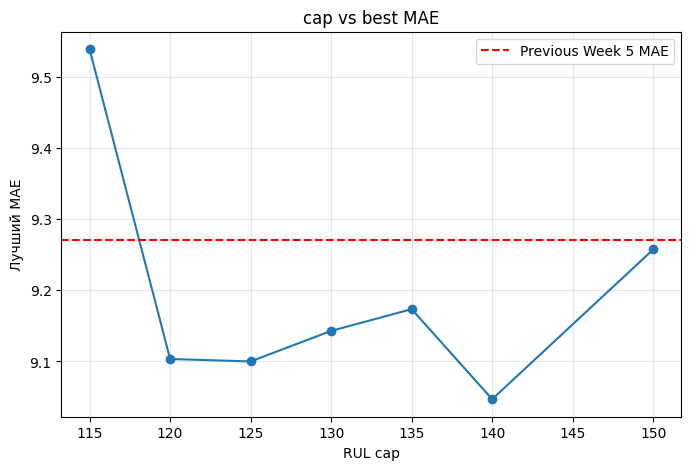

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(best_per_cap_df["cap"], best_per_cap_df["MAE"], marker="o")
plt.axhline(current_best_mae, color="red", linestyle="--", label="Previous Week 5 MAE")
plt.xlabel("RUL cap")
plt.ylabel("Лучший MAE")
plt.title("cap vs best MAE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

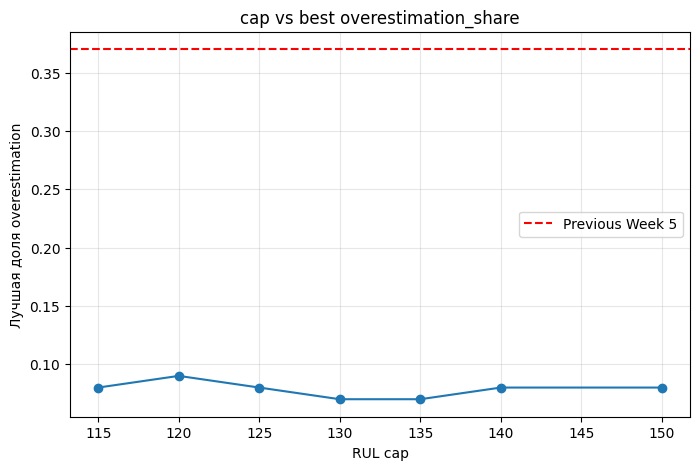

In [12]:
best_safety_per_cap_df = (
    cap_quantile_results_df.sort_values(
        ["cap", "overestimation_share", "max_overestimation", "MAE"]
    )
    .groupby("cap", as_index=False)
    .first()
)
plt.figure(figsize=(8, 5))
plt.plot(
    best_safety_per_cap_df["cap"],
    best_safety_per_cap_df["overestimation_share"],
    marker="o",
)
plt.axhline(
    previous_week5_overestimation_share,
    color="red",
    linestyle="--",
    label="Previous Week 5",
)
plt.xlabel("RUL cap")
plt.ylabel("Лучшая доля overestimation")
plt.title("cap vs best overestimation_share")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

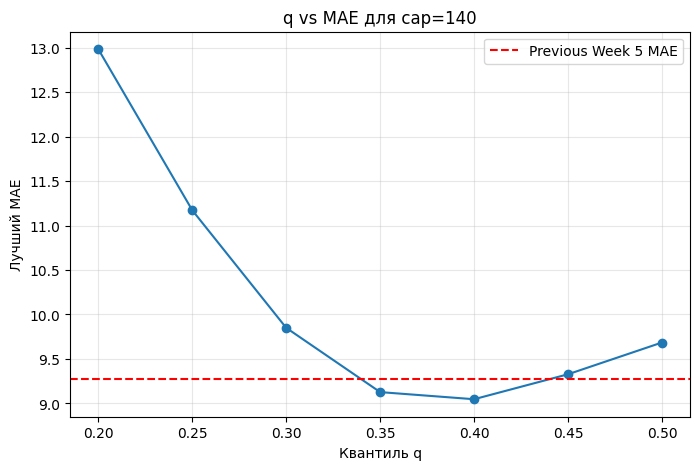

In [13]:
best_cap = int(best_cap_quantile["cap"])
best_cap_q_df = (
    cap_quantile_results_df[cap_quantile_results_df["cap"] == best_cap]
    .sort_values(["q", "MAE", "shift"])
    .groupby("q", as_index=False)
    .first()
)
plt.figure(figsize=(8, 5))
plt.plot(best_cap_q_df["q"], best_cap_q_df["MAE"], marker="o")
plt.axhline(current_best_mae, color="red", linestyle="--", label="Previous Week 5 MAE")
plt.xlabel("Квантиль q")
plt.ylabel("Лучший MAE")
plt.title(f"q vs MAE для cap={best_cap}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

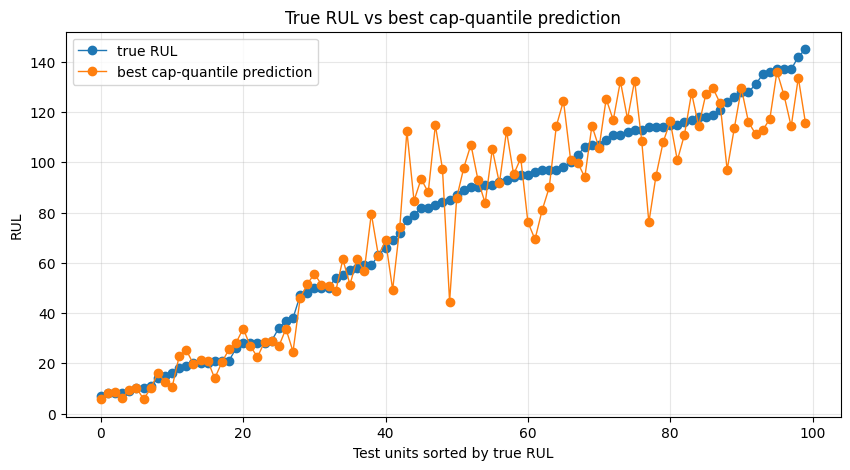

In [14]:
best_cap_tree_pred = cap_tree_predictions[best_cap]
best_cap_pred = np.maximum(
    np.quantile(best_cap_tree_pred, float(best_cap_quantile["q"]), axis=0)
    - float(best_cap_quantile["shift"]),
    0,
)
order = np.argsort(np.asarray(y_test_official))
plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(
    best_cap_pred[order], label="best cap-quantile prediction", marker="o", linewidth=1
)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("True RUL vs best cap-quantile prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

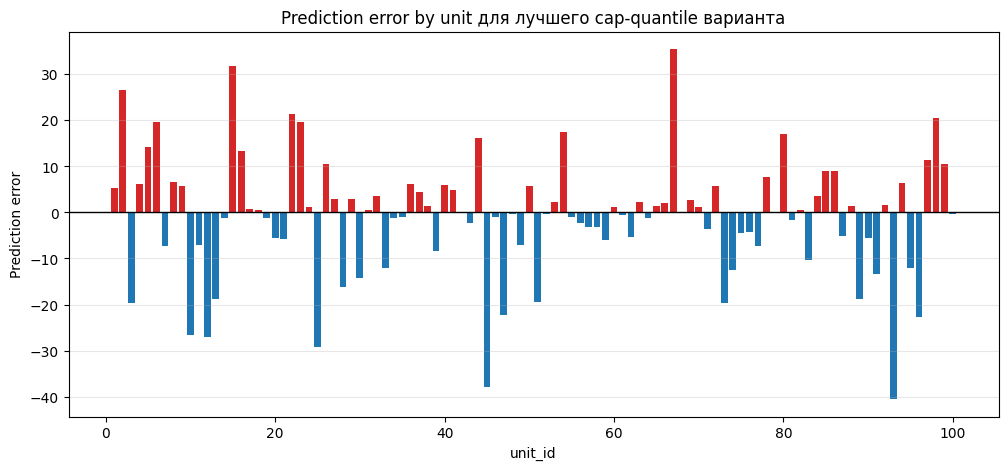

In [15]:
best_cap_error_df = build_error_table(
    y_test_official, best_cap_pred, "best cap-quantile", official_unit_ids
)
plt.figure(figsize=(12, 5))
colors = np.where(best_cap_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(best_cap_error_df["id"], best_cap_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для лучшего cap-quantile варианта")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 6. Piecewise quantile calibration

Проверяем разные квантильные уровни для near-failure, warning и long-RUL зон. Зону выбираем по среднему прогнозу RandomForest.

In [16]:
piecewise_tree_predictions = cap_tree_predictions[best_cap]
piecewise_pred_mean = cap_mean_predictions[best_cap]
piecewise_rows = []

for near_q in piecewise_near_q_grid:
    pred_near = np.quantile(piecewise_tree_predictions, near_q, axis=0)
    for warning_q in piecewise_warning_q_grid:
        pred_warning = np.quantile(piecewise_tree_predictions, warning_q, axis=0)
        for long_q in piecewise_long_q_grid:
            pred_long = np.quantile(piecewise_tree_predictions, long_q, axis=0)
            pred_piecewise_raw = np.where(
                piecewise_pred_mean <= 30,
                pred_near,
                np.where(piecewise_pred_mean <= 70, pred_warning, pred_long),
            )
            for shift in piecewise_shift_grid:
                pred_piecewise = np.maximum(pred_piecewise_raw - shift, 0)
                piecewise_rows.append(
                    evaluate_prediction_row(
                        "piecewise_quantile",
                        y_test_official,
                        pred_piecewise,
                        cap=best_cap,
                        q=np.nan,
                        quantile_strategy=f"near={near_q:.2f}; warning={warning_q:.2f}; long={long_q:.2f}",
                        shift=float(shift),
                        ids=official_unit_ids,
                        extra={
                            "near_q": near_q,
                            "warning_q": warning_q,
                            "long_q": long_q,
                        },
                    )
                )

piecewise_results_df = pd.DataFrame(piecewise_rows)
piecewise_results_df.sort_values(["MAE", "fitness", "shift"]).head(20)[
    ["method", "cap", "near_q", "warning_q", "long_q", "shift", *metric_columns]
]

,method,cap,near_q,warning_q,long_q,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
212,piecewise_quantile,140,0.50,0.40,0.40,1.0,12.446299,9.011675,12.999509,0.902142,-1.149194,0.49,34.915000,2.390316,5.898705
140,piecewise_quantile,140,0.45,0.40,0.40,1.0,12.379890,9.022959,13.006705,0.902034,-1.282637,0.47,34.915000,2.373868,5.989269
139,piecewise_quantile,140,0.45,0.40,0.40,0.5,12.561489,9.027638,12.966948,0.902632,-0.782637,0.51,35.415000,2.412583,5.959857
213,piecewise_quantile,140,0.50,0.40,0.40,1.5,12.340513,9.034342,13.053215,0.901332,-1.649194,0.46,34.415000,2.447649,5.947725
211,piecewise_quantile,140,0.50,0.40,0.40,0.5,12.701872,9.042092,12.964877,0.902663,-0.649194,0.54,35.415000,2.531983,5.869293
67,piecewise_quantile,140,0.40,0.40,0.40,0.5,12.545551,9.046854,12.977712,0.902470,-0.912936,0.50,35.415000,2.427917,6.050339
68,piecewise_quantile,140,0.40,0.40,0.40,1.0,12.350147,9.062020,13.022440,0.901797,-1.412936,0.45,34.915000,2.468584,6.079751
66,piecewise_quantile,140,0.40,0.40,0.40,0.0,12.745075,9.066358,12.952146,0.902854,-0.412936,0.54,35.915000,2.486317,6.059022
141,piecewise_quantile,140,0.45,0.40,0.40,1.5,12.302389,9.067055,13.065490,0.901147,-1.782637,0.44,34.415000,2.516916,6.038288
138,piecewise_quantile,140,0.45,0.40,0.40,0.0,12.868337,9.067843,12.946394,0.902940,-0.282637,0.57,35.915000,2.553783,5.968540


In [17]:
piecewise_results_df.sort_values(
    ["overestimation_share", "max_overestimation", "MAE", "fitness"]
).head(20)[["method", "cap", "near_q", "warning_q", "long_q", "shift", *metric_columns]]

,method,cap,near_q,warning_q,long_q,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
5,piecewise_quantile,140,0.40,0.30,0.25,2.5,14.295923,12.419831,17.173697,0.829208,-10.272960,0.15,23.6875,3.233895,7.668878
29,piecewise_quantile,140,0.40,0.35,0.25,2.5,14.188231,12.298616,17.081924,0.831028,-10.097206,0.16,23.6875,3.186451,7.101848
4,piecewise_quantile,140,0.40,0.30,0.25,2.0,13.971629,12.079831,16.879364,0.835012,-9.772960,0.16,24.1875,2.933895,7.286525
53,piecewise_quantile,140,0.40,0.40,0.25,2.5,14.090142,12.185959,17.013750,0.832374,-9.922620,0.17,23.6875,3.120584,6.597786
149,piecewise_quantile,140,0.50,0.30,0.25,2.5,14.225164,12.303645,17.133240,0.830012,-10.009218,0.17,23.6875,2.892262,7.487833
77,piecewise_quantile,140,0.45,0.30,0.25,2.5,14.289711,12.353532,17.150376,0.829671,-10.142661,0.17,23.6875,3.030227,7.578396
28,piecewise_quantile,140,0.40,0.35,0.25,2.0,13.876290,11.968616,16.791216,0.836731,-9.597206,0.17,24.1875,2.886451,6.778318
76,piecewise_quantile,140,0.45,0.30,0.25,2.0,13.938617,12.023532,16.859500,0.835400,-9.642661,0.17,24.1875,2.770227,7.196043
173,piecewise_quantile,140,0.50,0.35,0.25,2.5,14.117473,12.182430,17.041250,0.831832,-9.833464,0.18,23.6875,2.844818,6.920802
101,piecewise_quantile,140,0.45,0.35,0.25,2.5,14.182020,12.232317,17.058478,0.831492,-9.966907,0.18,23.6875,2.982783,7.011366


In [18]:
piecewise_balanced_pool = piecewise_results_df[
    (piecewise_results_df["MAE"] <= current_best_mae * 1.03)
    & (
        piecewise_results_df["overestimation_share"]
        <= previous_week5_overestimation_share
    )
]
if len(piecewise_balanced_pool):
    best_piecewise = piecewise_balanced_pool.sort_values(
        ["MAE", "fitness", "shift"]
    ).iloc[0]
else:
    best_piecewise = piecewise_results_df.sort_values(["MAE", "fitness", "shift"]).iloc[
        0
    ]

best_piecewise.to_frame().T[
    ["method", "cap", "near_q", "warning_q", "long_q", "shift", *metric_columns]
]

,method,cap,near_q,warning_q,long_q,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
70,piecewise_quantile,140,0.4,0.4,0.4,2.0,12.183463,9.207639,13.168516,0.899581,-2.412936,0.37,33.915,2.860584,6.238182


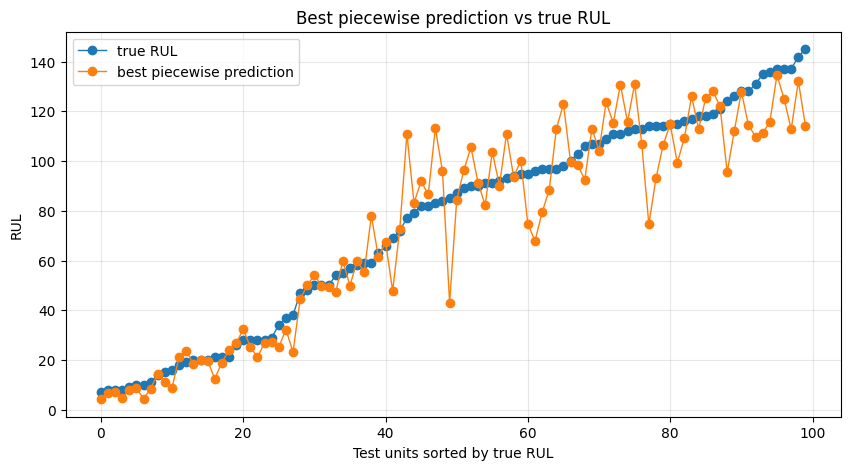

In [19]:
best_piecewise_pred_near = np.quantile(
    piecewise_tree_predictions, float(best_piecewise["near_q"]), axis=0
)
best_piecewise_pred_warning = np.quantile(
    piecewise_tree_predictions, float(best_piecewise["warning_q"]), axis=0
)
best_piecewise_pred_long = np.quantile(
    piecewise_tree_predictions, float(best_piecewise["long_q"]), axis=0
)
best_piecewise_raw = np.where(
    piecewise_pred_mean <= 30,
    best_piecewise_pred_near,
    np.where(
        piecewise_pred_mean <= 70, best_piecewise_pred_warning, best_piecewise_pred_long
    ),
)
best_piecewise_pred = np.maximum(best_piecewise_raw - float(best_piecewise["shift"]), 0)

plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(
    best_piecewise_pred[order],
    label="best piecewise prediction",
    marker="o",
    linewidth=1,
)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("Best piecewise prediction vs true RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

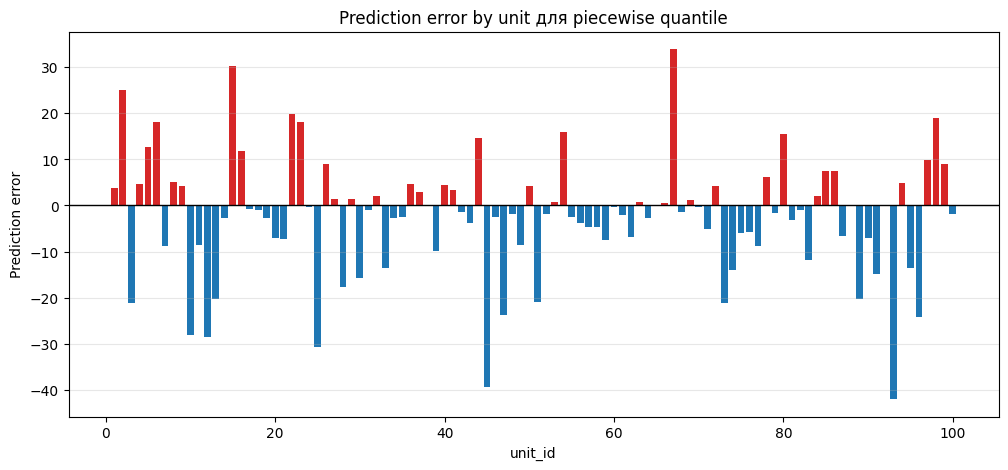

In [20]:
best_piecewise_error_df = build_error_table(
    y_test_official, best_piecewise_pred, "best piecewise", official_unit_ids
)
plt.figure(figsize=(12, 5))
colors = np.where(best_piecewise_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(best_piecewise_error_df["id"], best_piecewise_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для piecewise quantile")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

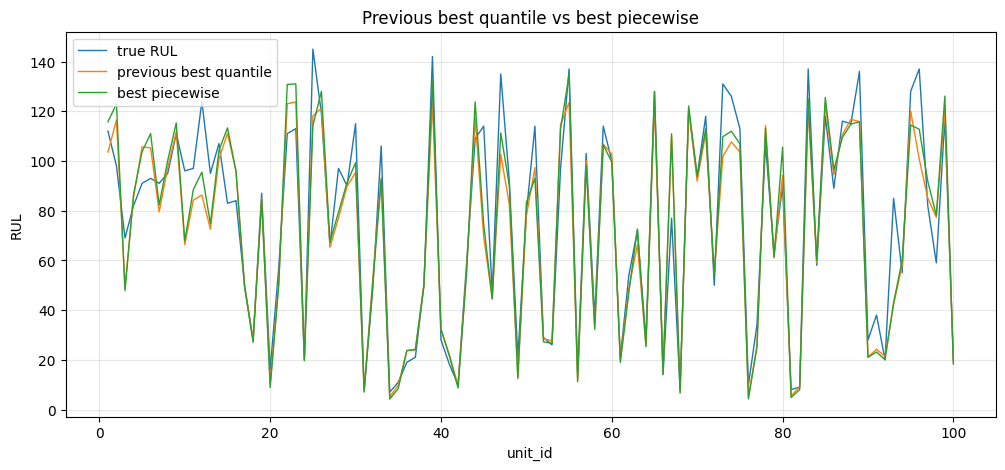

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(official_unit_ids, np.asarray(y_test_official), label="true RUL", linewidth=1)
plt.plot(
    official_unit_ids, previous_week5_pred, label="previous best quantile", linewidth=1
)
plt.plot(official_unit_ids, best_piecewise_pred, label="best piecewise", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("RUL")
plt.title("Previous best quantile vs best piecewise")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Uncertainty-based quantile calibration

Используем разброс предсказаний деревьев как меру уверенности RandomForest. При высокой uncertainty берём более осторожный нижний квантиль.

In [22]:
uncertainty_tree_predictions = cap_tree_predictions[best_cap]
uncertainty_q20 = np.quantile(uncertainty_tree_predictions, 0.20, axis=0)
uncertainty_q80 = np.quantile(uncertainty_tree_predictions, 0.80, axis=0)
uncertainty_measures = {
    "tree_std": uncertainty_tree_predictions.std(axis=0),
    "tree_iqr": uncertainty_q80 - uncertainty_q20,
}
threshold_functions = {
    "median": lambda values: np.quantile(values, 0.50),
    "q60": lambda values: np.quantile(values, 0.60),
    "q70": lambda values: np.quantile(values, 0.70),
    "q75": lambda values: np.quantile(values, 0.75),
    "q80": lambda values: np.quantile(values, 0.80),
}

uncertainty_rows = []
for uncertainty_measure, uncertainty_values in uncertainty_measures.items():
    for threshold_type in uncertainty_threshold_grid:
        threshold_value = float(threshold_functions[threshold_type](uncertainty_values))
        for low_uncertainty_q, high_uncertainty_q in uncertainty_quantile_pairs:
            pred_low_uncertainty = np.quantile(
                uncertainty_tree_predictions, low_uncertainty_q, axis=0
            )
            pred_high_uncertainty = np.quantile(
                uncertainty_tree_predictions, high_uncertainty_q, axis=0
            )
            pred_adaptive_raw = np.where(
                uncertainty_values <= threshold_value,
                pred_low_uncertainty,
                pred_high_uncertainty,
            )
            for shift in shift_grid:
                pred_adaptive = np.maximum(pred_adaptive_raw - shift, 0)
                uncertainty_rows.append(
                    evaluate_prediction_row(
                        "uncertainty_quantile",
                        y_test_official,
                        pred_adaptive,
                        cap=best_cap,
                        q=np.nan,
                        quantile_strategy=f"{uncertainty_measure}:{threshold_type}; low={low_uncertainty_q:.2f}; high={high_uncertainty_q:.2f}",
                        shift=float(shift),
                        ids=official_unit_ids,
                        extra={
                            "uncertainty_measure": uncertainty_measure,
                            "threshold_type": threshold_type,
                            "threshold_value": threshold_value,
                            "low_uncertainty_q": low_uncertainty_q,
                            "high_uncertainty_q": high_uncertainty_q,
                        },
                    )
                )

uncertainty_results_df = pd.DataFrame(uncertainty_rows)
uncertainty_results_df.sort_values(["MAE", "fitness", "shift"]).head(20)[
    [
        "method",
        "cap",
        "uncertainty_measure",
        "threshold_type",
        "threshold_value",
        "low_uncertainty_q",
        "high_uncertainty_q",
        "shift",
        *metric_columns,
    ]
]

,method,cap,uncertainty_measure,threshold_type,threshold_value,low_uncertainty_q,high_uncertainty_q,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
140,uncertainty_quantile,140,tree_std,q80,23.713392,0.40,0.3,0.0,12.479591,9.128374,13.220668,0.898784,-1.933279,0.46,35.915,2.486317,5.871543
141,uncertainty_quantile,140,tree_std,q80,23.713392,0.40,0.3,0.5,12.431496,9.178774,13.302982,0.897520,-2.433279,0.44,35.415,2.427917,5.900955
148,uncertainty_quantile,140,tree_std,q80,23.713392,0.45,0.3,0.5,12.850588,9.251076,13.420081,0.895708,-0.599362,0.50,38.500,2.515383,6.082048
142,uncertainty_quantile,140,tree_std,q80,23.713392,0.40,0.3,1.0,12.296092,9.253941,13.403455,0.895966,-2.933279,0.39,34.915,2.468584,5.930367
149,uncertainty_quantile,140,tree_std,q80,23.713392,0.45,0.3,1.0,12.636611,9.259572,13.451689,0.895216,-1.099362,0.45,38.000,2.436668,6.052636
147,uncertainty_quantile,140,tree_std,q80,23.713392,0.45,0.3,0.0,13.056662,9.267726,13.407058,0.895910,-0.099362,0.54,39.000,2.678183,6.117048
150,uncertainty_quantile,140,tree_std,q80,23.713392,0.45,0.3,1.5,12.504320,9.333977,13.501752,0.894435,-1.599362,0.40,37.500,2.525773,6.082048
143,uncertainty_quantile,140,tree_std,q80,23.713392,0.40,0.3,1.5,12.370786,9.367274,13.521682,0.894123,-3.433279,0.38,34.415,2.648584,5.979387
315,uncertainty_quantile,140,tree_iqr,q80,48.038000,0.40,0.3,0.0,12.802815,9.380389,13.555375,0.893595,-2.046372,0.48,35.915,2.486317,5.651768
316,uncertainty_quantile,140,tree_iqr,q80,48.038000,0.40,0.3,0.5,12.696719,9.414313,13.639815,0.892265,-2.546372,0.45,35.415,2.427917,5.643084


In [23]:
uncertainty_results_df.sort_values(
    ["overestimation_share", "max_overestimation", "MAE", "fitness"]
).head(20)[
    [
        "method",
        "cap",
        "uncertainty_measure",
        "threshold_type",
        "threshold_value",
        "low_uncertainty_q",
        "high_uncertainty_q",
        "shift",
        *metric_columns,
    ]
]

,method,cap,uncertainty_measure,threshold_type,threshold_value,low_uncertainty_q,high_uncertainty_q,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
195,uncertainty_quantile,140,tree_iqr,median,33.521825,0.45,0.25,3.0,14.788489,12.433021,17.313006,0.826426,-8.188877,0.23,30.693750,3.145773,6.574853
181,uncertainty_quantile,140,tree_iqr,median,33.521825,0.40,0.30,3.0,13.332316,11.047688,15.481002,0.861216,-7.041797,0.24,26.140000,3.447251,6.616193
20,uncertainty_quantile,140,tree_std,median,18.794194,0.45,0.25,3.0,14.899317,12.495025,17.346401,0.825755,-8.110881,0.24,30.693750,3.145773,6.795441
6,uncertainty_quantile,140,tree_std,median,18.794194,0.40,0.30,3.0,13.421284,11.092421,15.495814,0.860951,-6.985030,0.25,26.140000,3.447251,6.722075
180,uncertainty_quantile,140,tree_iqr,median,33.521825,0.40,0.30,2.5,13.093927,10.791021,15.260066,0.865149,-6.541797,0.25,26.640000,3.120584,6.351487
194,uncertainty_quantile,140,tree_iqr,median,33.521825,0.45,0.25,2.5,14.599082,12.176082,17.082193,0.831023,-7.688877,0.25,31.193750,2.925773,6.328151
41,uncertainty_quantile,140,tree_std,q60,20.821812,0.40,0.30,3.0,13.564551,11.036673,15.466628,0.861474,-6.418549,0.25,32.915000,3.447251,6.616193
55,uncertainty_quantile,140,tree_std,q60,20.821812,0.45,0.25,3.0,14.973317,12.378661,17.241826,0.827850,-6.974865,0.25,36.000000,3.145773,6.574853
5,uncertainty_quantile,140,tree_std,median,18.794194,0.40,0.30,2.5,13.192896,10.845755,15.276951,0.864851,-6.485030,0.26,26.640000,3.120584,6.457369
179,uncertainty_quantile,140,tree_iqr,median,33.521825,0.40,0.30,2.0,12.877539,10.551021,15.052502,0.868793,-6.041797,0.26,27.140000,2.860584,6.086781


In [24]:
uncertainty_balanced_pool = uncertainty_results_df[
    (uncertainty_results_df["MAE"] <= current_best_mae * 1.03)
    & (
        uncertainty_results_df["overestimation_share"]
        <= previous_week5_overestimation_share
    )
]
if len(uncertainty_balanced_pool):
    best_uncertainty = uncertainty_balanced_pool.sort_values(
        ["MAE", "fitness", "shift"]
    ).iloc[0]
else:
    best_uncertainty = uncertainty_results_df.sort_values(
        ["MAE", "fitness", "shift"]
    ).iloc[0]

best_uncertainty.to_frame().T[
    [
        "method",
        "cap",
        "uncertainty_measure",
        "threshold_type",
        "threshold_value",
        "low_uncertainty_q",
        "high_uncertainty_q",
        "shift",
        *metric_columns,
    ]
]

,method,cap,uncertainty_measure,threshold_type,threshold_value,low_uncertainty_q,high_uncertainty_q,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
144,uncertainty_quantile,140,tree_std,q80,23.713392,0.4,0.3,2.0,12.282253,9.512404,13.657202,0.89199,-3.933279,0.32,33.915,2.860584,6.088798


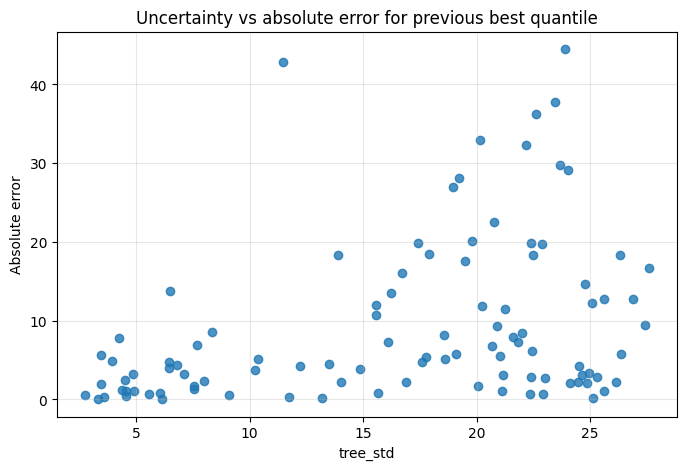

In [25]:
previous_error_df = build_error_table(
    y_test_official, previous_week5_pred, "previous best quantile", official_unit_ids
)
plt.figure(figsize=(8, 5))
plt.scatter(uncertainty_measures["tree_std"], previous_error_df["abs_error"], alpha=0.8)
plt.xlabel("tree_std")
plt.ylabel("Absolute error")
plt.title("Uncertainty vs absolute error for previous best quantile")
plt.grid(True, alpha=0.3)
plt.show()

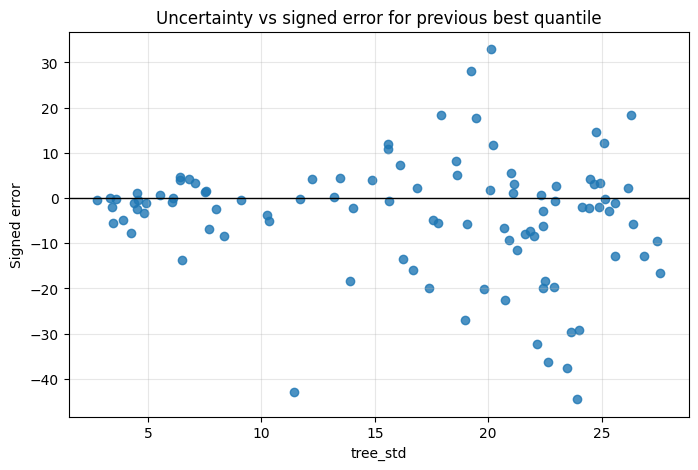

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(uncertainty_measures["tree_std"], previous_error_df["error"], alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("tree_std")
plt.ylabel("Signed error")
plt.title("Uncertainty vs signed error for previous best quantile")
plt.grid(True, alpha=0.3)
plt.show()

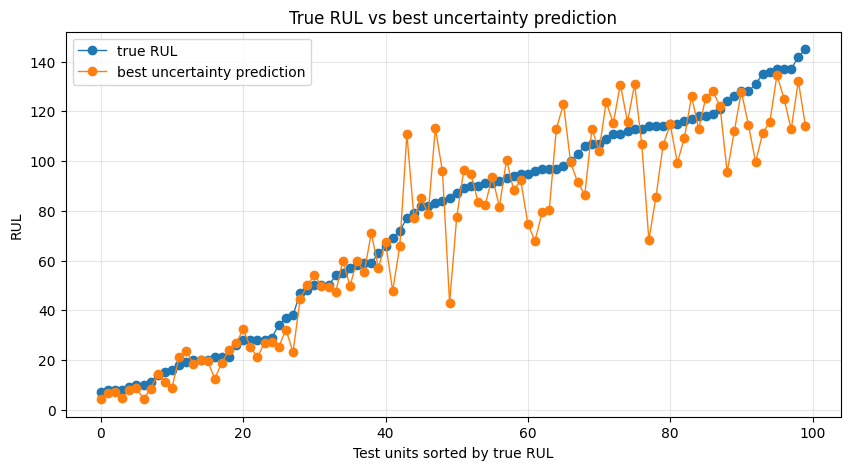

In [27]:
best_uncertainty_values = uncertainty_measures[best_uncertainty["uncertainty_measure"]]
best_uncertainty_low = np.quantile(
    uncertainty_tree_predictions, float(best_uncertainty["low_uncertainty_q"]), axis=0
)
best_uncertainty_high = np.quantile(
    uncertainty_tree_predictions, float(best_uncertainty["high_uncertainty_q"]), axis=0
)
best_uncertainty_raw = np.where(
    best_uncertainty_values <= float(best_uncertainty["threshold_value"]),
    best_uncertainty_low,
    best_uncertainty_high,
)
best_uncertainty_pred = np.maximum(
    best_uncertainty_raw - float(best_uncertainty["shift"]), 0
)

plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(
    best_uncertainty_pred[order],
    label="best uncertainty prediction",
    marker="o",
    linewidth=1,
)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("True RUL vs best uncertainty prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

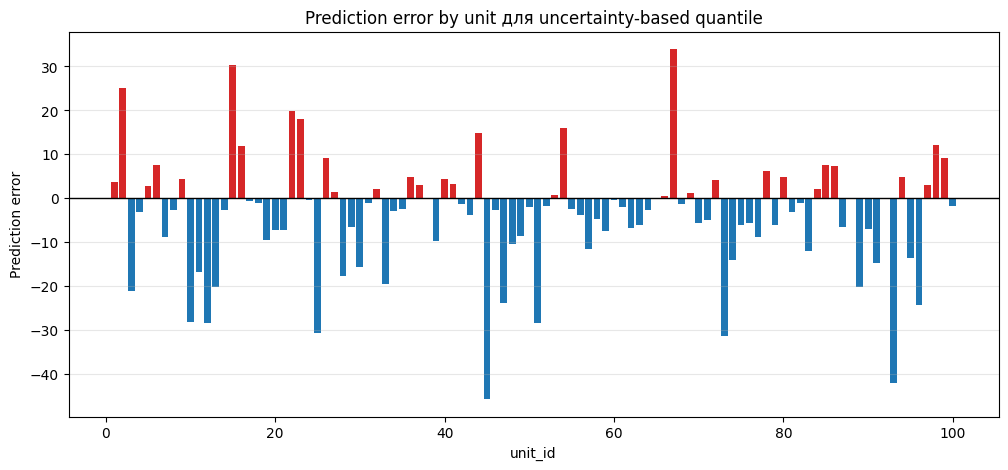

In [28]:
best_uncertainty_error_df = build_error_table(
    y_test_official, best_uncertainty_pred, "best uncertainty", official_unit_ids
)
plt.figure(figsize=(12, 5))
colors = np.where(best_uncertainty_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(
    best_uncertainty_error_df["id"], best_uncertainty_error_df["error"], color=colors
)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для uncertainty-based quantile")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 8. Quantile prediction ensemble одной модели

Смешиваем несколько quantile predictions одной и той же RandomForest-модели. Это не ensemble разных кандидатов, а сглаживание разных способов прочитать распределение деревьев.

In [29]:
ensemble_tree_predictions = cap_tree_predictions[best_cap]
q25 = np.quantile(ensemble_tree_predictions, 0.25, axis=0)
q30 = np.quantile(ensemble_tree_predictions, 0.30, axis=0)
q35 = np.quantile(ensemble_tree_predictions, 0.35, axis=0)
q40 = np.quantile(ensemble_tree_predictions, 0.40, axis=0)
q45 = np.quantile(ensemble_tree_predictions, 0.45, axis=0)
mean_prediction = ensemble_tree_predictions.mean(axis=0)

ensemble_predictions = {
    "median(q25,q35,q45)": np.median(np.vstack([q25, q35, q45]), axis=0),
    "mean(q25,q35,q45)": np.mean(np.vstack([q25, q35, q45]), axis=0),
    "0.7*q35+0.3*q40": 0.7 * q35 + 0.3 * q40,
    "0.6*q35+0.4*mean": 0.6 * q35 + 0.4 * mean_prediction,
    "0.5*q30+0.5*q40": 0.5 * q30 + 0.5 * q40,
    "0.5*q35+0.25*q30+0.25*q45": 0.5 * q35 + 0.25 * q30 + 0.25 * q45,
}

ensemble_rows = []
for ensemble_name, ensemble_pred_raw in ensemble_predictions.items():
    for shift in shift_grid:
        pred = np.maximum(ensemble_pred_raw - shift, 0)
        ensemble_rows.append(
            evaluate_prediction_row(
                "quantile_ensemble",
                y_test_official,
                pred,
                cap=best_cap,
                q=np.nan,
                quantile_strategy=ensemble_name,
                shift=float(shift),
                ids=official_unit_ids,
                extra={"ensemble_name": ensemble_name},
            )
        )

quantile_ensemble_results_df = pd.DataFrame(ensemble_rows)
quantile_ensemble_results_df[
    ["method", "cap", "ensemble_name", "shift", *metric_columns]
]

,method,cap,ensemble_name,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,quantile_ensemble,140,"median(q25,q35,q45)",0.0,12.199133,9.126762,13.217460,0.898834,-3.047407,0.42,32.438889,2.361845,5.756425
1,quantile_ensemble,140,"median(q25,q35,q45)",0.5,12.130002,9.224898,13.341613,0.896924,-3.547407,0.38,31.938889,2.414388,5.844660
2,quantile_ensemble,140,"median(q25,q35,q45)",1.0,12.111972,9.362036,13.483177,0.894725,-4.047407,0.34,31.438889,2.604940,5.959366
3,quantile_ensemble,140,"median(q25,q35,q45)",1.5,12.250728,9.528036,13.641608,0.892237,-4.547407,0.33,30.938889,2.848940,6.165249
4,quantile_ensemble,140,"median(q25,q35,q45)",2.0,12.287271,9.707624,13.816326,0.889458,-5.047407,0.29,30.438889,3.140293,6.381425
5,quantile_ensemble,140,"median(q25,q35,q45)",2.5,12.444893,9.922457,14.006722,0.886391,-5.547407,0.27,29.938889,3.480293,6.646131
6,quantile_ensemble,140,"median(q25,q35,q45)",3.0,12.620014,10.154791,14.212167,0.883034,-6.047407,0.25,29.438889,3.820293,6.910837
7,quantile_ensemble,140,"mean(q25,q35,q45)",0.0,12.246090,9.168844,13.288244,0.897747,-3.052628,0.42,32.542130,2.374821,5.774900
8,quantile_ensemble,140,"mean(q25,q35,q45)",0.5,12.175917,9.266191,13.411937,0.895835,-3.552628,0.38,32.042130,2.424208,5.863135
9,quantile_ensemble,140,"mean(q25,q35,q45)",1.0,12.162085,9.407639,13.552959,0.893633,-4.052628,0.34,31.542130,2.600748,6.003049


In [30]:
best_quantile_ensemble = quantile_ensemble_results_df.sort_values(
    ["MAE", "fitness", "shift"]
).iloc[0]
quantile_ensemble_results_df.sort_values(["MAE", "fitness", "shift"]).head(20)[
    ["method", "cap", "ensemble_name", "shift", *metric_columns]
]

,method,cap,ensemble_name,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
23,quantile_ensemble,140,0.6*q35+0.4*mean,1.0,12.289101,8.922427,12.761892,0.905687,-1.333776,0.47,35.036503,2.381176,6.127128
22,quantile_ensemble,140,0.6*q35+0.4*mean,0.5,12.607252,8.938138,12.719360,0.906315,-0.833776,0.54,35.536503,2.430055,6.215364
24,quantile_ensemble,140,0.6*q35+0.4*mean,1.5,12.207783,8.967211,12.823793,0.904770,-1.833776,0.44,34.536503,2.525934,6.060039
21,quantile_ensemble,140,0.6*q35+0.4*mean,0.0,12.820294,9.000473,12.696391,0.906653,-0.333776,0.57,36.036503,2.565484,6.337187
14,quantile_ensemble,140,0.7*q35+0.3*q40,0.0,12.249367,9.021116,13.059141,0.901243,-2.257066,0.45,33.481722,2.387667,5.819648
25,quantile_ensemble,140,0.6*q35+0.4*mean,2.0,12.167032,9.046829,12.904784,0.903563,-2.333776,0.41,34.036503,2.705934,6.065825
35,quantile_ensemble,140,0.5*q35+0.25*q30+0.25*q45,0.0,12.271375,9.050558,13.103229,0.900575,-2.370818,0.45,33.254444,2.383846,5.811896
15,quantile_ensemble,140,0.7*q35+0.3*q40,0.5,12.106937,9.090513,13.154780,0.899791,-2.757066,0.40,32.981722,2.398687,5.876952
36,quantile_ensemble,140,0.5*q35+0.25*q30+0.25*q45,0.5,12.135489,9.125407,13.202857,0.899057,-2.870818,0.40,32.754444,2.403017,5.880180
0,quantile_ensemble,140,"median(q25,q35,q45)",0.0,12.199133,9.126762,13.217460,0.898834,-3.047407,0.42,32.438889,2.361845,5.756425


In [31]:
quantile_ensemble_results_df.sort_values(
    ["overestimation_share", "max_overestimation", "MAE", "fitness"]
).head(20)[["method", "cap", "ensemble_name", "shift", *metric_columns]]

,method,cap,ensemble_name,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
6,quantile_ensemble,140,"median(q25,q35,q45)",3.0,12.620014,10.154791,14.212167,0.883034,-6.047407,0.25,29.438889,3.820293,6.910837
34,quantile_ensemble,140,0.5*q30+0.5*q40,3.0,12.717525,10.207327,14.268326,0.882107,-6.030743,0.26,29.527500,3.807938,6.993454
13,quantile_ensemble,140,"mean(q25,q35,q45)",3.0,12.743932,10.232739,14.279118,0.881929,-6.052628,0.26,29.542130,3.804369,7.014487
5,quantile_ensemble,140,"median(q25,q35,q45)",2.5,12.444893,9.922457,14.006722,0.886391,-5.547407,0.27,29.938889,3.480293,6.646131
12,quantile_ensemble,140,"mean(q25,q35,q45)",2.5,12.562122,9.995600,14.074465,0.885289,-5.552628,0.28,30.042130,3.464369,6.702722
11,quantile_ensemble,140,"mean(q25,q35,q45)",2.0,12.319334,9.775600,13.884810,0.888360,-5.052628,0.28,30.542130,3.124369,6.438016
33,quantile_ensemble,140,0.5*q30+0.5*q40,2.5,12.586680,9.980729,14.064295,0.885455,-5.530743,0.29,30.027500,3.467938,6.692277
41,quantile_ensemble,140,0.5*q35+0.25*q30+0.25*q45,3.0,12.611432,9.973524,13.961358,0.887126,-5.370818,0.29,30.254444,3.723432,6.809993
4,quantile_ensemble,140,"median(q25,q35,q45)",2.0,12.287271,9.707624,13.816326,0.889458,-5.047407,0.29,30.438889,3.140293,6.381425
40,quantile_ensemble,140,0.5*q35+0.25*q30+0.25*q45,2.5,12.378644,9.763524,13.776745,0.890091,-4.870818,0.29,30.754444,3.383432,6.545287


## 9. Финальное сравнение

Сравниваем предыдущий baseline, лучший cap refinement, piecewise calibration, uncertainty-based calibration и quantile ensemble одной модели.

In [32]:
def final_row(method, source, cap, quantile_strategy, shift, q=np.nan):
    values = source[metric_columns].to_dict()
    return {
        "method": method,
        "cap": cap,
        "q": q,
        "quantile_strategy": quantile_strategy,
        "shift": shift,
        **values,
    }


final_comparison_df = pd.DataFrame(
    [
        final_row(
            "Week 4 mean + shift",
            baseline_refinement_df[
                baseline_refinement_df["method"] == "Week 4 mean + shift"
            ].iloc[0],
            previous_best_cap,
            "mean",
            old_week4_shift,
        ),
        final_row(
            "Previous Week 5 best quantile",
            baseline_refinement_df[
                baseline_refinement_df["method"] == "Previous Week 5 best quantile"
            ].iloc[0],
            previous_best_cap,
            f"q{previous_best_q:.2f}",
            previous_best_shift,
            previous_best_q,
        ),
        final_row(
            "Best cap-refined quantile",
            best_cap_quantile,
            int(best_cap_quantile["cap"]),
            f"q{best_cap_quantile['q']:.2f}",
            float(best_cap_quantile["shift"]),
            float(best_cap_quantile["q"]),
        ),
        final_row(
            "Best piecewise quantile",
            best_piecewise,
            best_cap,
            best_piecewise["quantile_strategy"],
            float(best_piecewise["shift"]),
        ),
        final_row(
            "Best uncertainty-based quantile",
            best_uncertainty,
            best_cap,
            best_uncertainty["quantile_strategy"],
            float(best_uncertainty["shift"]),
        ),
        final_row(
            "Best quantile ensemble",
            best_quantile_ensemble,
            best_cap,
            best_quantile_ensemble["ensemble_name"],
            float(best_quantile_ensemble["shift"]),
        ),
    ]
)
final_comparison_df = final_comparison_df.sort_values("MAE").reset_index(drop=True)
final_comparison_df[display_columns]

,method,cap,q,quantile_strategy,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Best quantile ensemble,140,NaN,0.6*q35+0.4*mean,1.0,12.289101,8.922427,12.761892,0.905687,-1.333776,0.47,35.036503,2.381176,6.127128
1,Best cap-refined quantile,140,0.40,q0.40,0.5,12.545551,9.046854,12.977712,0.902470,-0.912936,0.50,35.415000,2.427917,6.050339
2,Best piecewise quantile,140,NaN,near=0.40; warning=0.40; long=0.40,2.0,12.183463,9.207639,13.168516,0.899581,-2.412936,0.37,33.915000,2.860584,6.238182
3,Previous Week 5 best quantile,125,0.35,q0.35,0.5,12.161329,9.273059,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873
4,Week 4 mean + shift,125,NaN,mean,2.0,12.946757,9.449429,13.159902,0.899713,-1.378648,0.48,35.059084,2.579192,7.980507
5,Best uncertainty-based quantile,140,NaN,tree_std:q80; low=0.40; high=0.30,2.0,12.282253,9.512404,13.657202,0.891990,-3.933279,0.32,33.915000,2.860584,6.088798


In [33]:
best_overall_by_mae = final_comparison_df.sort_values(["MAE", "fitness"]).iloc[0]
safety_final_pool = final_comparison_df[
    final_comparison_df["MAE"] <= current_best_mae * 1.03
]
if len(safety_final_pool):
    best_safety_final = safety_final_pool.sort_values(
        ["overestimation_share", "max_overestimation", "MAE", "fitness"]
    ).iloc[0]
else:
    best_safety_final = final_comparison_df.sort_values(
        ["overestimation_share", "max_overestimation", "MAE", "fitness"]
    ).iloc[0]

final_summary_df = pd.DataFrame(
    [
        {"summary": "best overall by MAE", **best_overall_by_mae.to_dict()},
        {"summary": "best safety among close MAE", **best_safety_final.to_dict()},
        {
            "summary": "any method achieved MAE < 9.0",
            "method": bool((final_comparison_df["MAE"] < 9.0).any()),
            "cap": np.nan,
            "q": np.nan,
            "quantile_strategy": "",
            "shift": np.nan,
            "fitness": np.nan,
            "MAE": final_comparison_df["MAE"].min(),
            "RMSE": np.nan,
            "R2": np.nan,
            "mean_error": np.nan,
            "overestimation_share": np.nan,
            "max_overestimation": np.nan,
            "near_failure_MAE": np.nan,
            "warning_zone_MAE": np.nan,
        },
    ]
)
final_summary_df[
    ["summary", "method", "cap", "q", "quantile_strategy", "shift", *metric_columns]
]

,summary,method,cap,q,quantile_strategy,shift,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,best overall by MAE,Best quantile ensemble,140.0,NaN,0.6*q35+0.4*mean,1.0,12.289101,8.922427,12.761892,0.905687,-1.333776,0.47,35.036503,2.381176,6.127128
1,best safety among close MAE,Best uncertainty-based quantile,140.0,NaN,tree_std:q80; low=0.40; high=0.30,2.0,12.282253,9.512404,13.657202,0.891990,-3.933279,0.32,33.915000,2.860584,6.088798
2,any method achieved MAE < 9.0,True,NaN,NaN,,NaN,NaN,8.922427,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Выводы

Если лучший MAE оказался ниже 9, refinement позволил перейти в диапазон 8.x без нейросетей за счёт более гибкой quantile calibration.

Если лучший MAE улучшился относительно предыдущего результата, но остался выше 9, метод дал дополнительный умеренный прирост, однако барьер 8.x пока не преодолён.

Если улучшения нет, предыдущая Week 5 quantile-модель остаётся лучшей, а более сложная адаптивная калибровка не перенеслась лучше на official test.

Cap refinement проверяет, не слишком ли сильно cap=125 ограничивает верхний RUL. Piecewise quantile учитывает разные зоны предсказанного RUL. Uncertainty-based quantile использует разброс деревьев как меру уверенности модели. Quantile ensemble сглаживает нестабильность выбора одного quantile.

## 11. Ограничения эксперимента

Эксперимент ограничен refinement-вариантами quantile calibration одной лучшей RandomForest-модели.